In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Data import and check

In [17]:
HI_dmax = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc')
ATL3 = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/OISST/ATL3.nc')
ONI = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/OISST/ONI.nc')
HI_dmax_month_anom = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmax_month_anom.nc')

In [18]:
HI_dmax

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [19]:
ATL3

<xarray.Dataset> Size: 6kB
Dimensions:     (time: 537)
Coordinates:
  * time        (time) datetime64[ns] 4kB 1981-09-30 1981-10-31 ... 2026-05-31
Data variables:
    ATL3_OISST  (time) float32 2kB ...

In [20]:
ONI

<xarray.Dataset> Size: 6kB
Dimensions:    (time: 537)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-30 1981-10-31 ... 2026-05-31
Data variables:
    ONI_OISST  (time) float32 2kB ...

# Adjust data ranges to match

In [21]:
idate = '1981-09-30'
fdate = '2026-02-28'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
ATL3 = ATL3['ATL3_OISST'].sel(time=slice(idate, fdate))
ONI = ONI['ONI_OISST'].sel(time=slice(idate, fdate))
HI_dmax_month_anom = HI_dmax_month_anom['HI_dmax_anom'].sel(time=slice(idate, fdate))

# ONI HI

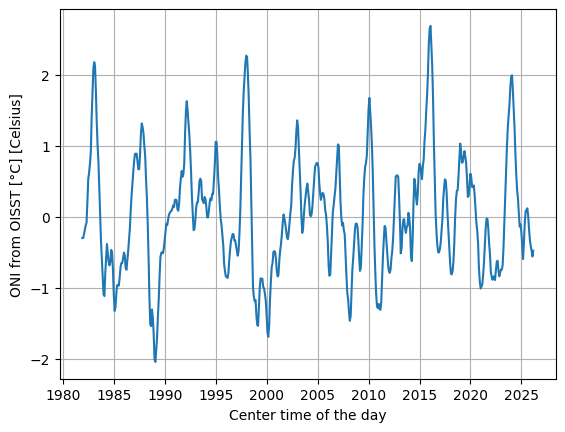

In [41]:
ONI.plot()
plt.grid()

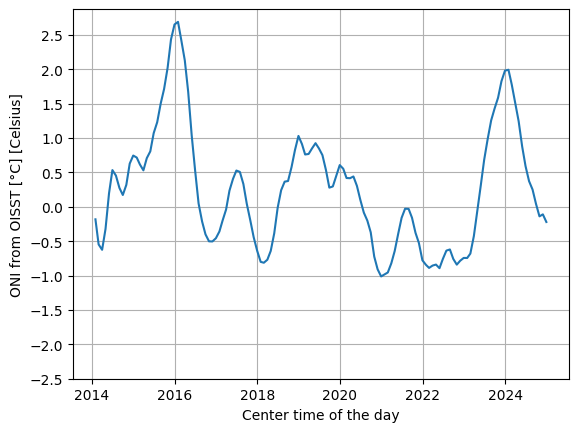

In [57]:
years = np.arange(2014, 2025, 1)
ONI.where(ONI['time.year'].isin(years)).plot()
plt.yticks(np.arange(-2.5, 3, 0.5))
plt.grid()

## Mean values

In [23]:
meanHI_hotONI = HI_dmax.resample(time='ME').mean('time').where(ONI >= 0.5, drop=True).mean('time')
meanHI_hotONI

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[87.152176, 87.259445, 87.376724, ..., 94.55124 , 93.408806,
        90.406624],
       [87.183655, 87.34183 , 87.4786  , ..., 93.836395, 90.17904 ,
        85.74272 ],
       [87.201416, 87.31236 , 87.46868 , ..., 88.36072 , 85.80789 ,
        86.06222 ],
       ...,
       [78.53589 , 78.57012 , 78.62386 , ..., 77.75035 , 77.71848 ,
        77.71006 ],
       [78.181885, 78.204475, 78.243065, ..., 77.54908 , 77.5249  ,
        77.50363 ],
       [77.86176 , 77.87802 , 77.84817 , ..., 77.35356 , 77.32261 ,
        77.32553 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index [°F] during months with ONI ≥ 0.5°C')

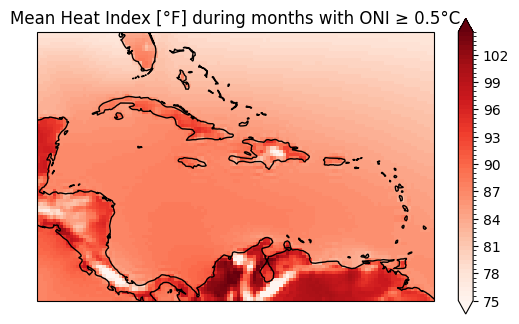

In [25]:
meanHI_hotONI_plot = meanHI_hotONI.plot(transform=ccrs.PlateCarree(),
                                        cmap='Reds',
                                        levels=np.arange(75, 105, 0.5),
                                        subplot_kws={'projection': ccrs.PlateCarree()},
                                        cbar_kwargs={'orientation': 'vertical',
                                                     'shrink': 0.8,
                                                     'location': 'right'},
                                         add_labels=False
                                        )
plt.gca().coastlines()
plt.title('Mean Heat Index [°F] during months with ONI ≥ 0.5°C')

## Mean Anomalies

In [10]:
meanHIanom_hotONI = HI_dmax_month_anom.resample(time='ME').mean('time').where(ONI >= 0.5, drop=True).mean('time')
meanHIanom_hotONI

<xarray.DataArray 'HI_dmax_anom' (latitude: 82, longitude: 121)> Size: 40kB
array([[3.7737405 , 3.781219  , 3.7808166 , ..., 1.8653761 , 1.7826741 ,
        1.7004042 ],
       [3.8507519 , 3.8419468 , 3.8353398 , ..., 1.7969713 , 1.7047141 ,
        1.455444  ],
       [3.8768349 , 3.87952   , 3.8801413 , ..., 1.7863418 , 1.4390166 ,
        1.3341051 ],
       ...,
       [0.24020836, 0.23741885, 0.23696092, ..., 0.73227966, 0.74027014,
        0.74525595],
       [0.1963393 , 0.1913774 , 0.19017161, ..., 0.7271472 , 0.73157126,
        0.7372642 ],
       [0.15947948, 0.1479745 , 0.14870325, ..., 0.73697734, 0.72897995,
        0.73057276]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index Anomaly [°F] during months with ONI ≥ 0.5°C')

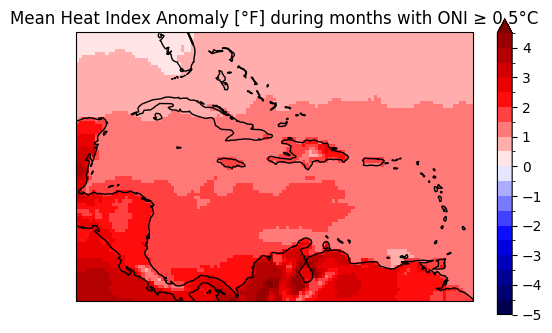

In [11]:
meanHIanom_hotONI_plot = meanHIanom_hotONI.plot(transform=ccrs.PlateCarree(),
                                        cmap='seismic',
                                        levels=np.arange(-5, 5, 0.5),
                                        subplot_kws={'projection': ccrs.PlateCarree()},
                                        cbar_kwargs={'orientation': 'vertical',
                                                     'shrink': 0.8,
                                                     'location': 'right'},
                                         add_labels=False
                                        )
plt.gca().coastlines()
plt.title('Mean Heat Index Anomaly [°F] during months with ONI ≥ 0.5°C')

# ATL HI

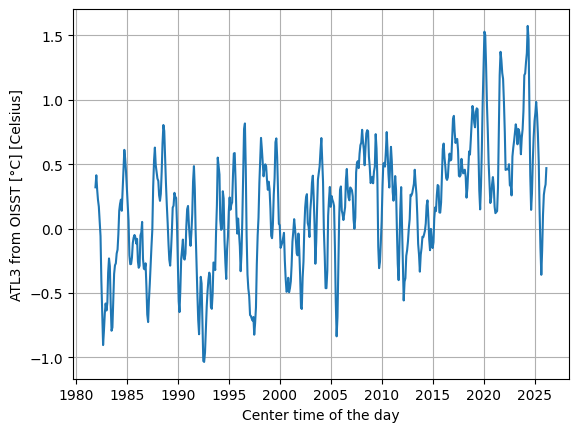

In [26]:
ATL3.plot()
plt.grid()

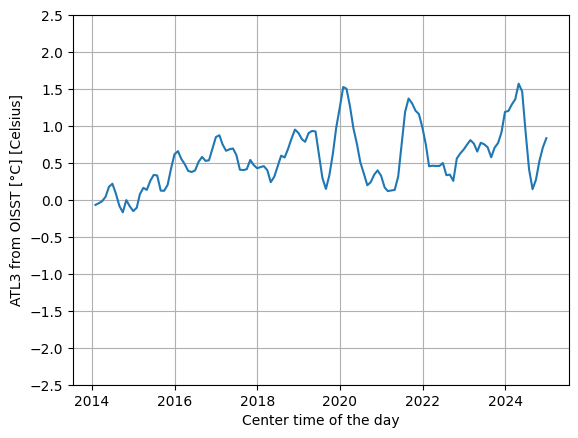

In [58]:
ATL3.where(ATL3['time.year'].isin(years)).plot()
plt.yticks(np.arange(-2.5, 3, 0.5))
plt.grid()

## Mean Values

In [27]:
meanHI_hotATL3 = HI_dmax.resample(time='ME').mean('time').where(ATL3 >= 0.5, drop=True).mean('time')
meanHI_hotATL3

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[85.38372 , 85.50092 , 85.64532 , ..., 95.62057 , 94.50903 ,
        91.418915],
       [85.34839 , 85.558815, 85.71953 , ..., 94.93877 , 91.11791 ,
        86.364716],
       [85.37226 , 85.51705 , 85.714775, ..., 89.18944 , 86.44477 ,
        86.774734],
       ...,
       [80.06402 , 80.07788 , 80.105194, ..., 78.22486 , 78.17416 ,
        78.14898 ],
       [79.733154, 79.73708 , 79.746864, ..., 78.04327 , 78.00453 ,
        77.9728  ],
       [79.44071 , 79.453354, 79.397934, ..., 77.857574, 77.827866,
        77.81369 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index [°F] during months with ATL3 ≥ 0.5°C')

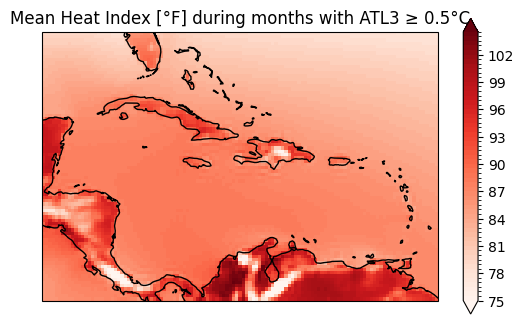

In [28]:
meanHI_hotATL3_plot = meanHI_hotATL3.plot(transform=ccrs.PlateCarree(),
                                          cmap='Reds',
                                          levels=np.arange(75, 105, 0.5),
                                          subplot_kws={'projection': ccrs.PlateCarree()},
                                          cbar_kwargs={'orientation': 'vertical',
                                                       'shrink': 0.8,
                                                       'location': 'right'},
                                          add_labels=False
                                          )
plt.gca().coastlines()
plt.title('Mean Heat Index [°F] during months with ATL3 ≥ 0.5°C')

## Mean Anomalies

In [24]:
meanHIanom_hotATL3 = HI_dmax_month_anom.resample(time='ME').mean('time').where(ATL3 >= 0.5, drop=True).mean('time')
meanHIanom_hotATL3

<xarray.DataArray 'HI_dmax_anom' (latitude: 82, longitude: 121)> Size: 40kB
array([[1.9132069 , 1.9334763 , 1.9626896 , ..., 2.8649933 , 2.8148546 ,
        2.6474922 ],
       [1.9148303 , 1.9601604 , 1.9819725 , ..., 2.8241012 , 2.5766022 ,
        2.0326893 ],
       [1.9391956 , 1.977488  , 2.02093   , ..., 2.545489  , 2.0274599 ,
        2.0008361 ],
       ...,
       [1.1384257 , 1.1177222 , 1.0927709 , ..., 0.914649  , 0.9061132 ,
        0.8975513 ],
       [1.102597  , 1.0818765 , 1.0536648 , ..., 0.9259104 , 0.91847444,
        0.9167189 ],
       [1.0774416 , 1.0642512 , 1.0437118 , ..., 0.94348806, 0.93899167,
        0.92571336]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index Anomaly [°F] during months with ATL3 ≥ 0.5°C')

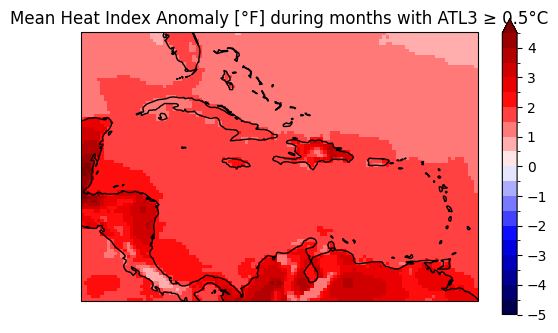

In [52]:
meanHIanom_hotATL3_plot = meanHIanom_hotATL3.plot(transform=ccrs.PlateCarree(),
                                                  cmap='seismic',
                                                  levels=np.arange(-5, 5, 0.5),
                                                  subplot_kws={'projection': ccrs.PlateCarree()},
                                                  cbar_kwargs={'orientation': 'vertical',
                                                               'shrink': 0.8,
                                                               'location': 'right'},
                                                   add_labels=False
                                                  )
plt.gca().coastlines()
plt.title('Mean Heat Index Anomaly [°F] during months with ATL3 ≥ 0.5°C')

# ATL3 but neutral ENSO

## mean values

In [32]:
# just for curiosity
HI_hotATL3notONI = HI_dmax.resample(time='ME').mean('time')
meanHI_hotATL3notONI = HI_hotATL3notONI.where(((ATL3 >= 0.5) & ((ONI < 0.5) & (ONI > -0.5))), drop=True).mean('time')
meanHI_hotATL3notONI

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[85.06833 , 85.20356 , 85.37617 , ..., 95.8929  , 94.81422 ,
        91.65074 ],
       [85.04973 , 85.26849 , 85.44324 , ..., 95.309135, 91.33364 ,
        86.43361 ],
       [85.10235 , 85.238335, 85.45583 , ..., 89.33185 , 86.54473 ,
        86.890976],
       ...,
       [82.415276, 82.41538 , 82.43833 , ..., 79.21886 , 79.16237 ,
        79.11772 ],
       [82.137344, 82.13136 , 82.14386 , ..., 79.064445, 79.017624,
        78.968475],
       [81.9287  , 81.92143 , 81.86848 , ..., 78.882996, 78.841484,
        78.81649 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index [°F] during months with ATL3 ≥ 0.5°C but Neutral ENSO')

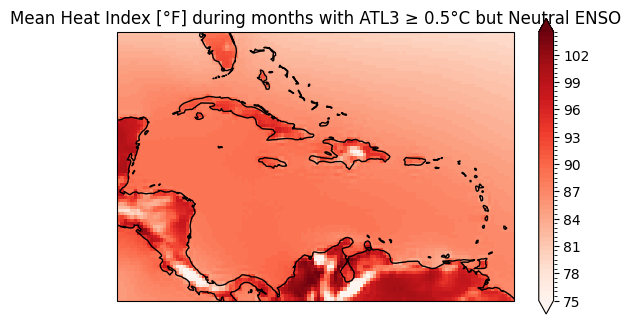

In [33]:
meanHI_hotATL3notONI_plot = meanHI_hotATL3notONI.plot(transform=ccrs.PlateCarree(),
                                                      cmap='Reds',
                                                      levels=np.arange(75, 105, 0.5),
                                                      subplot_kws={'projection': ccrs.PlateCarree()},
                                                      cbar_kwargs={'orientation': 'vertical',
                                                                   'shrink': 0.8,
                                                                   'location': 'right'},
                                                      add_labels=False
                                                      )
plt.gca().coastlines()
plt.title('Mean Heat Index [°F] during months with ATL3 ≥ 0.5°C but Neutral ENSO')

## anomaly

In [29]:
# just for curiosity
HIanom_hotATL3notONI = HI_dmax_month_anom.resample(time='ME').mean('time')
meanHIanom_hotATL3notONI = HIanom_hotATL3notONI.where(((ATL3 >= 0.5) & ((ONI < 0.5) & (ONI > -0.5))), drop=True).mean('time')
meanHIanom_hotATL3notONI

<xarray.DataArray 'HI_dmax_anom' (latitude: 82, longitude: 121)> Size: 40kB
array([[1.2404207 , 1.2983737 , 1.3737806 , ..., 2.709579  , 2.6967673 ,
        2.4783294 ],
       [1.2004105 , 1.2708559 , 1.3331249 , ..., 2.7427897 , 2.3906171 ,
        1.7794157 ],
       [1.1983327 , 1.244437  , 1.3245567 , ..., 2.2834773 , 1.7906272 ,
        1.7883039 ],
       ...,
       [1.2666472 , 1.242157  , 1.2181374 , ..., 0.8024823 , 0.794975  ,
        0.7776279 ],
       [1.2251791 , 1.2047627 , 1.1841936 , ..., 0.82611644, 0.8190633 ,
        0.80946416],
       [1.2204558 , 1.1957991 , 1.1897806 , ..., 0.8378012 , 0.8286511 ,
        0.8120685 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index Anomaly [°F] during months with ATL3 ≥ 0.5°C but Neutral ENSO')

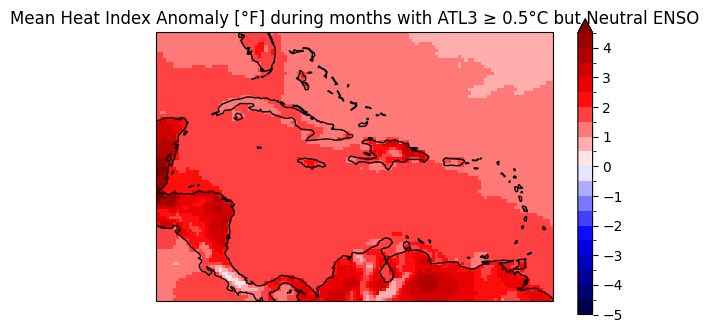

In [31]:
meanHIanom_hotATL3notONI_plot = meanHIanom_hotATL3notONI.plot(transform=ccrs.PlateCarree(),
                                                              cmap='seismic',
                                                              levels=np.arange(-5, 5, 0.5),
                                                              subplot_kws={'projection': ccrs.PlateCarree()},
                                                              cbar_kwargs={'orientation': 'vertical',
                                                                           'shrink': 0.8,
                                                                           'location': 'right'},
                                                               add_labels=False
                                                              )
plt.gca().coastlines()
plt.title('Mean Heat Index Anomaly [°F] during months with ATL3 ≥ 0.5°C but Neutral ENSO')

# ENSO but neutral ATL3

## mean values

In [34]:
HI_hotONInotATL3 = HI_dmax.resample(time='ME').mean('time')
meanHI_hotONInotATL3 = HI_hotONInotATL3.where(((ONI >= 0.5) & ((ATL3 > -0.5) & (ATL3 < 0.5))), drop=True).mean('time')
meanHI_hotONInotATL3

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[86.359085, 86.4706  , 86.596306, ..., 94.417175, 93.27969 ,
        90.31745 ],
       [86.40625 , 86.572556, 86.72416 , ..., 93.78633 , 90.13976 ,
        85.803665],
       [86.43773 , 86.552795, 86.72507 , ..., 88.37685 , 85.87294 ,
        86.13097 ],
       ...,
       [78.67789 , 78.702774, 78.75153 , ..., 78.13413 , 78.107   ,
        78.10725 ],
       [78.33816 , 78.355354, 78.38768 , ..., 77.934494, 77.91312 ,
        77.89449 ],
       [78.03009 , 78.0363  , 78.00366 , ..., 77.74229 , 77.71273 ,
        77.720314]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index [°F] during months with ONI ≥ 0.5°C but Neutral ATL3')

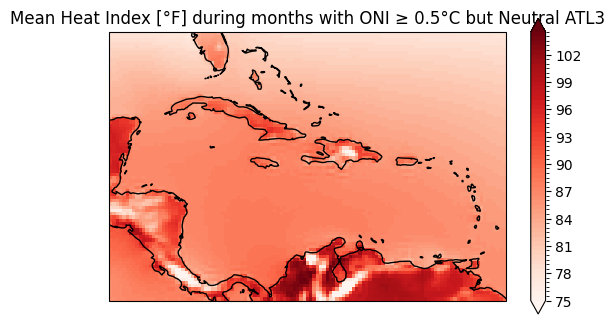

In [36]:
meanHI_hotONInotATL3_plot = meanHI_hotONInotATL3.plot(transform=ccrs.PlateCarree(),
                                                      cmap='Reds',
                                                      levels=np.arange(75, 105, 0.5),
                                                      subplot_kws={'projection': ccrs.PlateCarree()},
                                                      cbar_kwargs={'orientation': 'vertical',
                                                                   'shrink': 0.8,
                                                                   'location': 'right'},
                                                      add_labels=False
                                                      )
plt.gca().coastlines()
plt.title('Mean Heat Index [°F] during months with ONI ≥ 0.5°C but Neutral ATL3')

## Anomalies

In [43]:
# just for curiosity
HIanom_hotONInotATL3 = HI_dmax_month_anom.resample(time='ME').mean('time')
meanHIanom_hotONInotATL3 = HIanom_hotONInotATL3.where(((ONI >= 0.5) & ((ATL3 >= -0.5) & (ATL3 <= 0.5))), drop=True).mean('time')
meanHIanom_hotONInotATL3

<xarray.DataArray 'HI_dmax_anom' (latitude: 82, longitude: 121)> Size: 40kB
array([[ 3.1300704 ,  3.1538825 ,  3.1732676 , ...,  1.2916691 ,
         1.2088298 ,  1.1835014 ],
       [ 3.190743  ,  3.1981695 ,  3.2184048 , ...,  1.2989503 ,
         1.2442429 ,  1.1205462 ],
       [ 3.1966047 ,  3.2158427 ,  3.244229  , ...,  1.3887058 ,
         1.1127182 ,  1.0211431 ],
       ...,
       [ 0.01966881,  0.01028   ,  0.00855182, ...,  0.6421927 ,
         0.6555991 ,  0.66927993],
       [-0.01800348, -0.0259507 , -0.03094489, ...,  0.6358718 ,
         0.6436651 ,  0.6526126 ],
       [-0.0525758 , -0.07098052, -0.07078433, ...,  0.64744127,
         0.6408155 ,  0.6465186 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index Anomaly [°F] during months with ONI ≥ 0.5°C but Neutral ATL3')

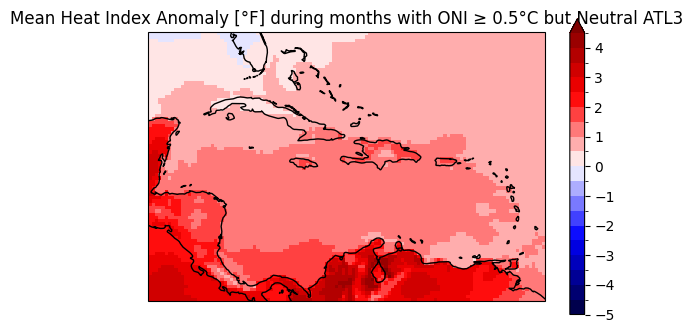

In [54]:
meanHIanom_hotONInotATL3_plot = meanHIanom_hotONInotATL3.plot(transform=ccrs.PlateCarree(),
                                                              cmap='seismic',
                                                              levels=np.arange(-5, 5, 0.5),
                                                              subplot_kws={'projection': ccrs.PlateCarree()},
                                                              cbar_kwargs={'orientation': 'vertical',
                                                                           'shrink': 0.8,
                                                                           'location': 'right'},
                                                               add_labels=False
                                                              )
plt.gca().coastlines()
plt.title('Mean Heat Index Anomaly [°F] during months with ONI ≥ 0.5°C but Neutral ATL3')

# ATL3 AND ONI

## Mean values

In [37]:
HI_hotATL3andONI = HI_dmax.resample(time='ME').mean('time')
meanHI_hotONIandATL3 = HI_hotATL3andONI.where(((ONI >= 0.5) & (ATL3 >= 0.5)), drop=True).mean('time')
meanHI_hotONIandATL3

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[89.28341 , 89.38791 , 89.48098 , ..., 96.46811 , 95.27088 ,
        92.193565],
       [89.29531 , 89.44295 , 89.55375 , ..., 95.5171  , 91.85224 ,
        87.03309 ],
       [89.28794 , 89.39673 , 89.52916 , ..., 89.980515, 87.06908 ,
        87.2862  ],
       ...,
       [77.84805 , 77.87675 , 77.91743 , ..., 76.983116, 76.9501  ,
        76.921   ],
       [77.4377  , 77.44515 , 77.46736 , ..., 76.765495, 76.73247 ,
        76.71067 ],
       [77.0534  , 77.06271 , 77.01184 , ..., 76.55361 , 76.51948 ,
        76.51319 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index [°F] during months with ONI and ATL3 ≥ 0.5°C')

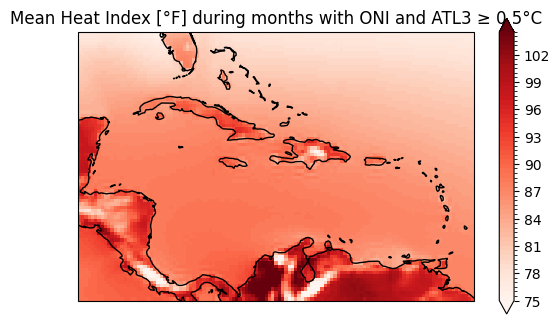

In [38]:
meanHI_hotONIandATL3_plot = meanHI_hotONIandATL3.plot(transform=ccrs.PlateCarree(),
                                                      cmap='Reds',
                                                      levels=np.arange(75, 105, 0.5),
                                                      subplot_kws={'projection': ccrs.PlateCarree()},
                                                      cbar_kwargs={'orientation': 'vertical',
                                                                   'shrink': 0.8,
                                                                   'location': 'right'},
                                                      add_labels=False
                                                      )
plt.gca().coastlines()
plt.title('Mean Heat Index [°F] during months with ONI and ATL3 ≥ 0.5°C')

## Anomalies

In [62]:
HIanom_hotATL3andONI = HI_dmax_month_anom.resample(time='ME').mean('time')
meanHIanom_hotONIandATL3 = HIanom_hotATL3andONI.where(((ONI >= 0.5) & (ATL3 >= 0.5)), drop=True).mean('time')
meanHIanom_hotONIandATL3

<xarray.DataArray 'HI_dmax_anom' (latitude: 82, longitude: 121)> Size: 40kB
array([[5.569278 , 5.5452585, 5.4955373, ..., 4.610772 , 4.4923296,
        4.302761 ],
       [5.7223544, 5.682912 , 5.6209307, ..., 4.365118 , 4.1815157,
        3.508754 ],
       [5.8234916, 5.7924995, 5.742701 , ..., 4.1868014, 3.4713876,
        3.3358715],
       ...,
       [1.3096312, 1.2937806, 1.270697 , ..., 1.4726391, 1.4743602,
        1.4527093],
       [1.2557111, 1.2279629, 1.2039076, ..., 1.4671592, 1.4570124,
        1.4553387],
       [1.2071424, 1.1811291, 1.1506348, ..., 1.4716349, 1.4567384,
        1.4455037]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index Anomaly [°F] during months with ONI and ATL3 >= 0.5°C')

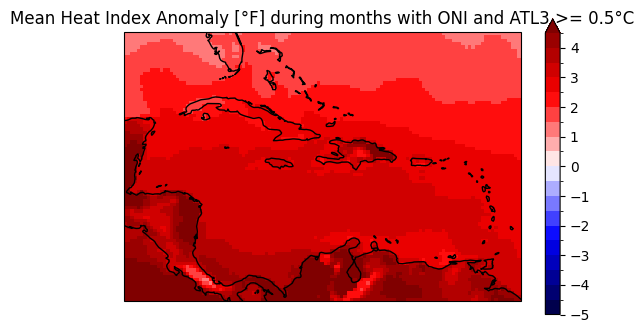

In [55]:
meanHIanom_hotONIandATL3_plot = meanHIanom_hotONIandATL3.plot(transform=ccrs.PlateCarree(),
                                                              cmap='seismic',
                                                              levels=np.arange(-5, 5, 0.5),
                                                              subplot_kws={'projection': ccrs.PlateCarree()},
                                                              cbar_kwargs={'orientation': 'vertical',
                                                                           'shrink': 0.8,
                                                                           'location': 'right'},
                                                               add_labels=False
                                                              )
plt.gca().coastlines()
plt.title('Mean Heat Index Anomaly [°F] during months with ONI and ATL3 >= 0.5°C')

# Cold phases

## Pacific Niña

### mean values

In [78]:
meanHI_coldONI = HI_dmax.resample(time='ME').mean('time').where(ONI <= -0.5, drop=True).mean('time')
meanHI_coldONI

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[82.08507 , 82.234184, 82.40602 , ..., 92.32575 , 91.2686  ,
        88.35941 ],
       [81.90404 , 82.11329 , 82.30686 , ..., 91.68653 , 88.12206 ,
        83.826195],
       [81.757965, 81.923004, 82.12075 , ..., 86.26122 , 83.92595 ,
        84.31112 ],
       ...,
       [76.67545 , 76.725075, 76.77897 , ..., 76.027756, 75.99398 ,
        75.999466],
       [76.32405 , 76.36014 , 76.3938  , ..., 75.818886, 75.809204,
        75.803925],
       [75.98752 , 76.03301 , 75.995346, ..., 75.61631 , 75.61687 ,
        75.63013 ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index [°F] during months with ONI <= -0.5°C')

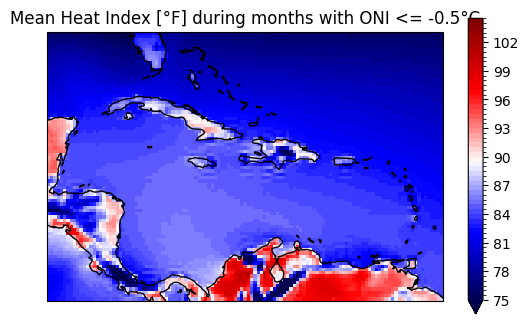

In [80]:
meanHI_coldONI_plot = meanHI_coldONI.plot(transform=ccrs.PlateCarree(),
                                                      cmap='seismic',
                                                      levels=np.arange(75, 105, 0.5),
                                                      subplot_kws={'projection': ccrs.PlateCarree()},
                                                      cbar_kwargs={'orientation': 'vertical',
                                                                   'shrink': 0.8,
                                                                   'location': 'right'},
                                                      add_labels=False
                                                      )
plt.gca().coastlines()
plt.title('Mean Heat Index [°F] during months with ONI <= -0.5°C')

### anomalies

In [81]:
meanHIanom_coldONI = HI_dmax_month_anom.resample(time='ME').mean('time').where(ONI <= -0.5, drop=True).mean('time')
meanHIanom_coldONI

<xarray.DataArray 'HI_dmax_anom' (latitude: 82, longitude: 121)> Size: 40kB
array([[-1.3654339 , -1.340171  , -1.3065003 , ...,  0.1575624 ,
         0.17127874,  0.16444568],
       [-1.4160807 , -1.393889  , -1.370591  , ...,  0.22221579,
         0.15557782,  0.02033989],
       [-1.467233  , -1.4366097 , -1.4169893 , ...,  0.18471192,
         0.05560276,  0.09848093],
       ...,
       [ 0.45621717,  0.46116847,  0.4535482 , ...,  0.328586  ,
         0.3288817 ,  0.3393813 ],
       [ 0.46971807,  0.47015786,  0.45883128, ...,  0.33180642,
         0.3434021 ,  0.35695598],
       [ 0.4770528 ,  0.48810998,  0.4691308 , ...,  0.34660333,
         0.3640793 ,  0.37019676]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 1.0, 'Mean Heat Index Anomaly [°F] during months with ONI <= -0.5°C')

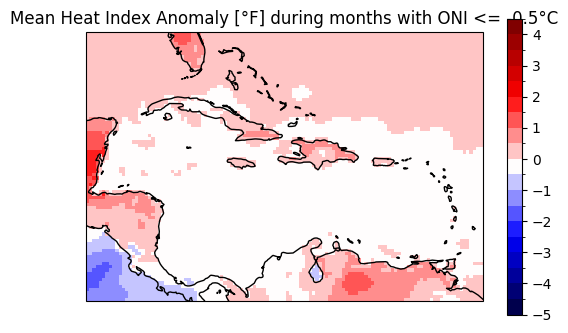

In [84]:
meanHIanom_coldONI_plot = meanHIanom_coldONI.plot(transform=ccrs.PlateCarree(),
                                                      cmap='seismic',
                                                      levels=np.arange(-5, 5, 0.5),
                                                      subplot_kws={'projection': ccrs.PlateCarree()},
                                                      cbar_kwargs={'orientation': 'vertical',
                                                                   'shrink': 0.8,
                                                                   'location': 'right'},
                                                      add_labels=False
                                                      )
plt.gca().coastlines()
plt.title('Mean Heat Index Anomaly [°F] during months with ONI <= -0.5°C')

## Atlantic Niña

In [85]:
meanHI_coldATL3 = HI_dmax.resample(time='ME').mean('time').where(ATL3 <= -0.5, drop=True).mean('time')
meanHI_coldATL3

<xarray.DataArray 'HI_daily_max' (latitude: 82, longitude: 121)> Size: 40kB
array([[85.68824 , 85.81371 , 85.94411 , ..., 91.75871 , 90.71297 ,
        87.76468 ],
       [85.63593 , 85.78574 , 85.93383 , ..., 91.119125, 87.56216 ,
        83.47813 ],
       [85.561775, 85.67054 , 85.81751 , ..., 85.69111 , 83.573685,
        83.865005],
       ...,
       [78.57531 , 78.63564 , 78.72322 , ..., 77.12546 , 77.075676,
        77.05126 ],
       [78.26907 , 78.317924, 78.40339 , ..., 76.92634 , 76.892815,
        76.85681 ],
       [78.02263 , 78.07299 , 78.08318 , ..., 76.7249  , 76.69006 ,
        76.6779  ]], shape=(82, 121), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0